# 🚢 Titanic Survival Analysis

## 📌 Objective
The goal of this project is to analyze the Titanic dataset and identify key factors that influenced passenger survival.

This project demonstrates:
- Data cleaning
- Exploratory Data Analysis (EDA)
- Feature engineering
- Data visualization

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [23]:
train_data = pd.read_csv("../data/train.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 📊 Data Overview
We explore the dataset structure, data types, and basic statistics.

In [24]:
train_data.shape

(891, 12)

In [25]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [26]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## ❗ Missing Values
We check for missing data that may impact analysis.

In [27]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [28]:
missing_age = train_data["Age"].isnull().sum()
print(f"Missing Age values: {missing_age}")

Missing Age values: 177


## 📈 Age Distribution
Most passengers are between 20–40 years old.

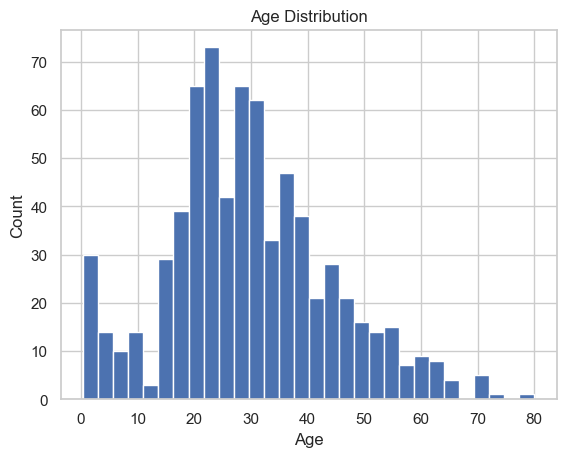

In [45]:
plt.figure()
train_data["Age"].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.savefig("../images/age_distribution.png")
plt.show()

## 📦 Fare Outliers
We remove outliers using the IQR method.

In [30]:
Q1 = train_data["Fare"].quantile(0.25)
Q3 = train_data["Fare"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = train_data[(train_data["Fare"] >= lower_bound) & 
                (train_data["Fare"] <= upper_bound)]

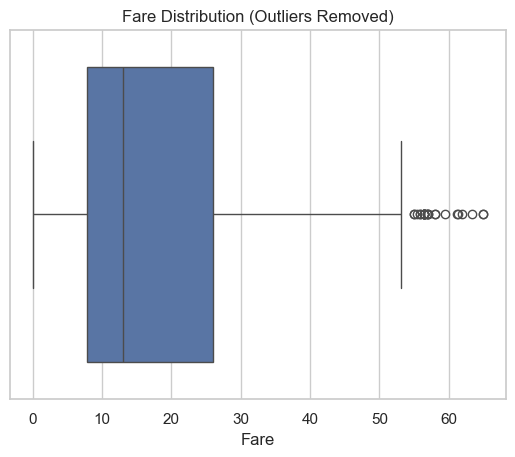

In [31]:
plt.figure()
sns.boxplot(x=df["Fare"])
plt.title("Fare Distribution (Outliers Removed)")
plt.show()

## 🔍 Relationship Analysis
We explore how different features relate to survival.

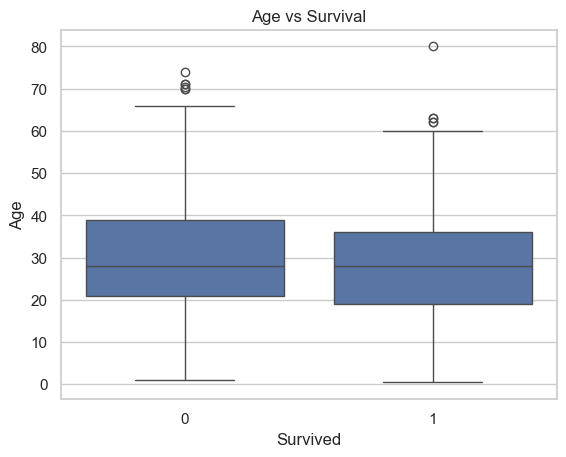

In [32]:
sns.boxplot(x="Survived", y="Age", data=train_data)
plt.title("Age vs Survival")
plt.show()

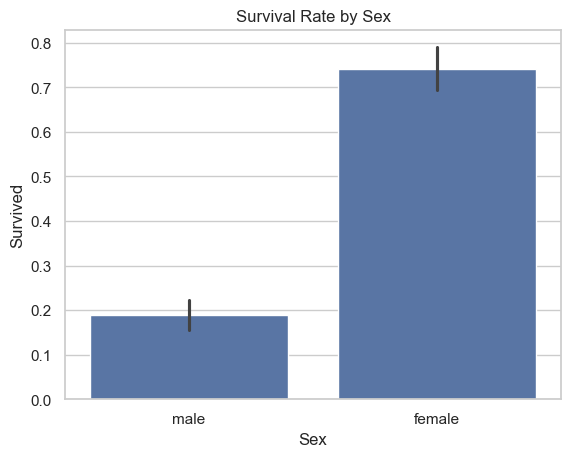

In [44]:
sns.barplot(data=train_data, x="Sex", y="Survived")
plt.title("Survival Rate by Sex")
plt.savefig("../images/survival_by_sex.png")
plt.show()

Females have a significantly higher survival rate than males.

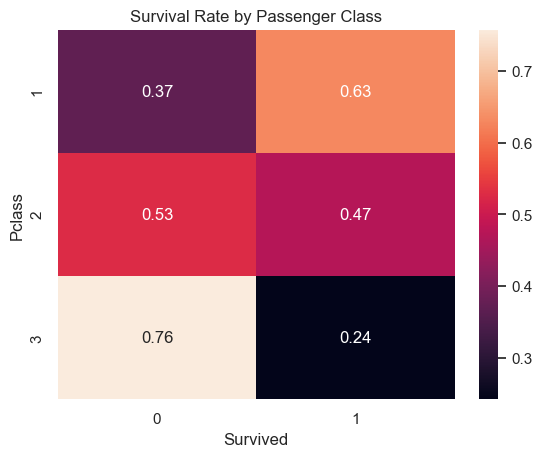

In [34]:
ct = pd.crosstab(train_data["Pclass"], train_data["Survived"], normalize="index")

sns.heatmap(ct, annot=True, fmt=".2f")
plt.title("Survival Rate by Passenger Class")
plt.show()

## 🔗 Correlation Analysis
We examine relationships between numerical features.

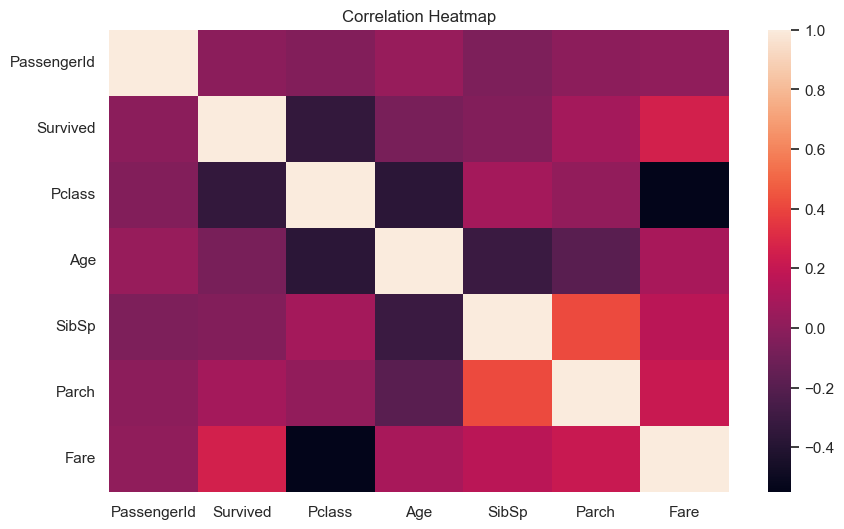

In [46]:
numeric_cols = train_data.select_dtypes(include=["int64", "float64"]).columns
corr = train_data[numeric_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=False)
plt.title("Correlation Heatmap")
plt.savefig("../images/heatmap.png")
plt.show()

In [36]:
corr["Survived"].sort_values(ascending=False)

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

## 🧠 Feature Engineering
We create new features to extract more meaningful insights.

In [37]:
df = train_data.copy()

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

df["Title"] = df["Name"].str.extract(r',\s*(\w+)\.', expand=False)

In [38]:
df["Title"].value_counts().head(10)

Title
Mr        517
Miss      182
Mrs       125
Master     40
Dr          7
Rev         6
Mlle        2
Major       2
Col         2
Don         1
Name: count, dtype: int64

In [39]:
df.groupby("IsAlone")["Survived"].mean()

IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64

Passengers traveling alone had lower survival rates.

In [40]:
df.groupby("Title")["Survived"].mean().sort_values(ascending=False).head(10)

Title
Lady      1.000000
Sir       1.000000
Mme       1.000000
Mlle      1.000000
Ms        1.000000
Mrs       0.792000
Miss      0.697802
Master    0.575000
Major     0.500000
Col       0.500000
Name: Survived, dtype: float64

Certain titles (e.g., Mrs, Miss) are strongly associated with higher survival rates.

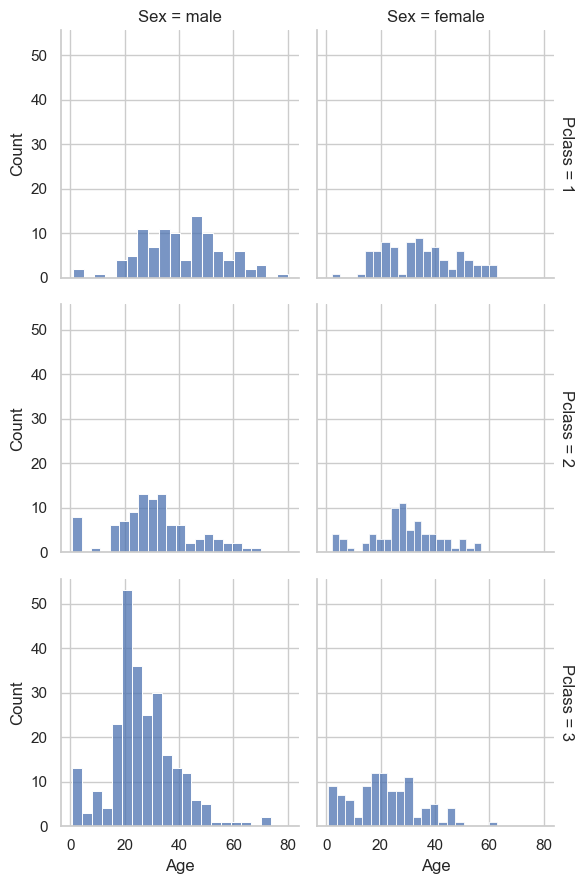

In [41]:
g = sns.FacetGrid(train_data, col="Sex", row="Pclass", margin_titles=True)
g.map_dataframe(sns.histplot, x="Age", bins=20)
plt.show()

## 📊 Key Insights

- Women had significantly higher survival rates than men
- First-class passengers were more likely to survive
- Passengers traveling alone had lower survival chances
- Age has weak correlation with survival
- Titles extracted from names provide strong predictive insights

## ✅ Conclusion

This analysis highlights the importance of gender, class, and social factors in survival outcomes.

The project demonstrates fundamental data analysis skills including:
- Data cleaning
- Visualization
- Feature engineering
- Insight generation